<a href="https://colab.research.google.com/github/eng20260311/AIFFEL_quest_eng/blob/master/Data_Analysis/DA02/housingdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [63]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np

import missingno as msno

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
train_data_path = '/content/sample_data/kaggle-kakr-housing-data/data/train.csv'
#sub_data_path = os.path.join(data_dir, 'test.csv')      # 테스트, 즉 submission 시 사용할 데이터 경로
sub_data_path = '/content/sample_data/kaggle-kakr-housing-data/data/test.csv'

print(train_data_path)
print(sub_data_path)

/content/sample_data/kaggle-kakr-housing-data/data/train.csv
/content/sample_data/kaggle-kakr-housing-data/data/test.csv


1. 데이터 살펴보기
pandas의 read_csv 함수를 사용해 데이터를 읽어오고, 각 변수들이 나타내는 의미를 살펴보겠습니다.

ID : 집을 구분하는 번호/
date : 집을 구매한 날짜/
price : 타겟 변수인 집의 가격/
bedrooms : 침실의 수/
bathrooms : 침실당 화장실 개수/
sqft_living : 주거 공간의 평방 피트/
sqft_lot : 부지의 평방 피트/
floors : 집의 층 수/
waterfront : 집의 전방에 강이 흐르는지 유무 (a.k.a. 리버뷰)/
view : 집이 얼마나 좋아 보이는지의 정도/
condition : 집의 전반적인 상태/
grade : King County grading 시스템 기준으로 매긴 집의 등급/
sqft_above : 지하실을 제외한 평방 피트/
sqft_basement : 지하실의 평방 피트/
yr_built : 집을 지은 년도/
yr_renovated : 집을 재건축한 년도/
zipcode : 우편번호/
lat : 위도/
long : 경도/
sqft_living15 : 2015년 기준 주거 공간의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)/
sqft_lot15 : 2015년 기준 부지의 평방 피트(집을 재건축했다면, 변화가 있을 수 있음)/

In [65]:
data = pd.read_csv(train_data_path)
sub = pd.read_csv(sub_data_path)
print('train data dim : {}'.format(data.shape))
print('sub data dim : {}'.format(sub.shape))

train data dim : (15035, 21)
sub data dim : (6468, 20)


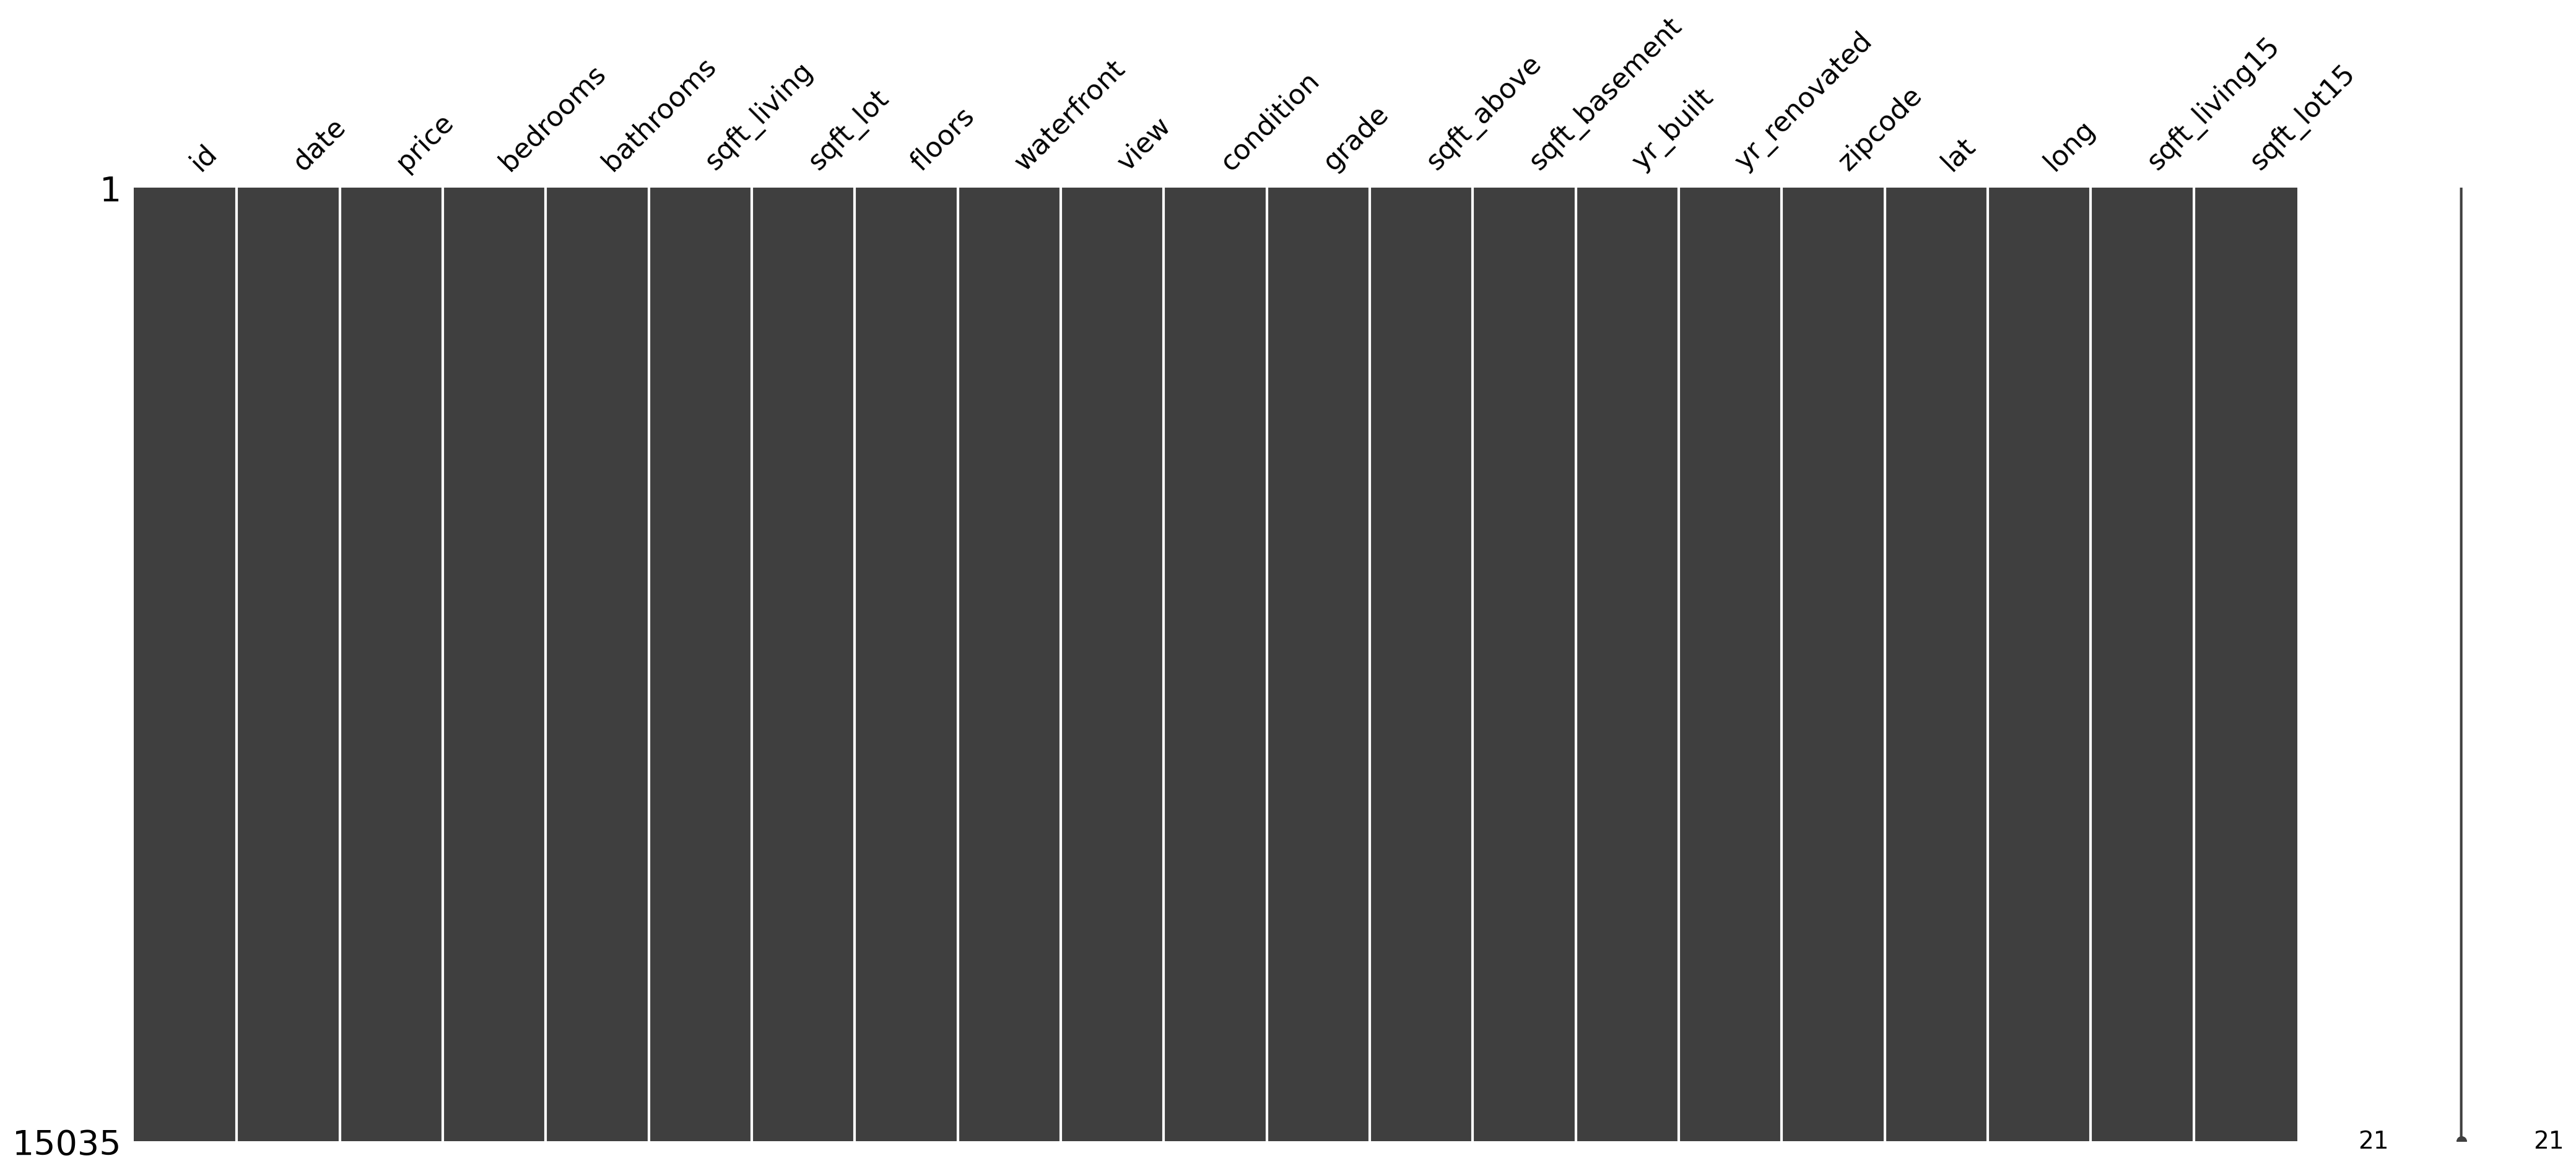

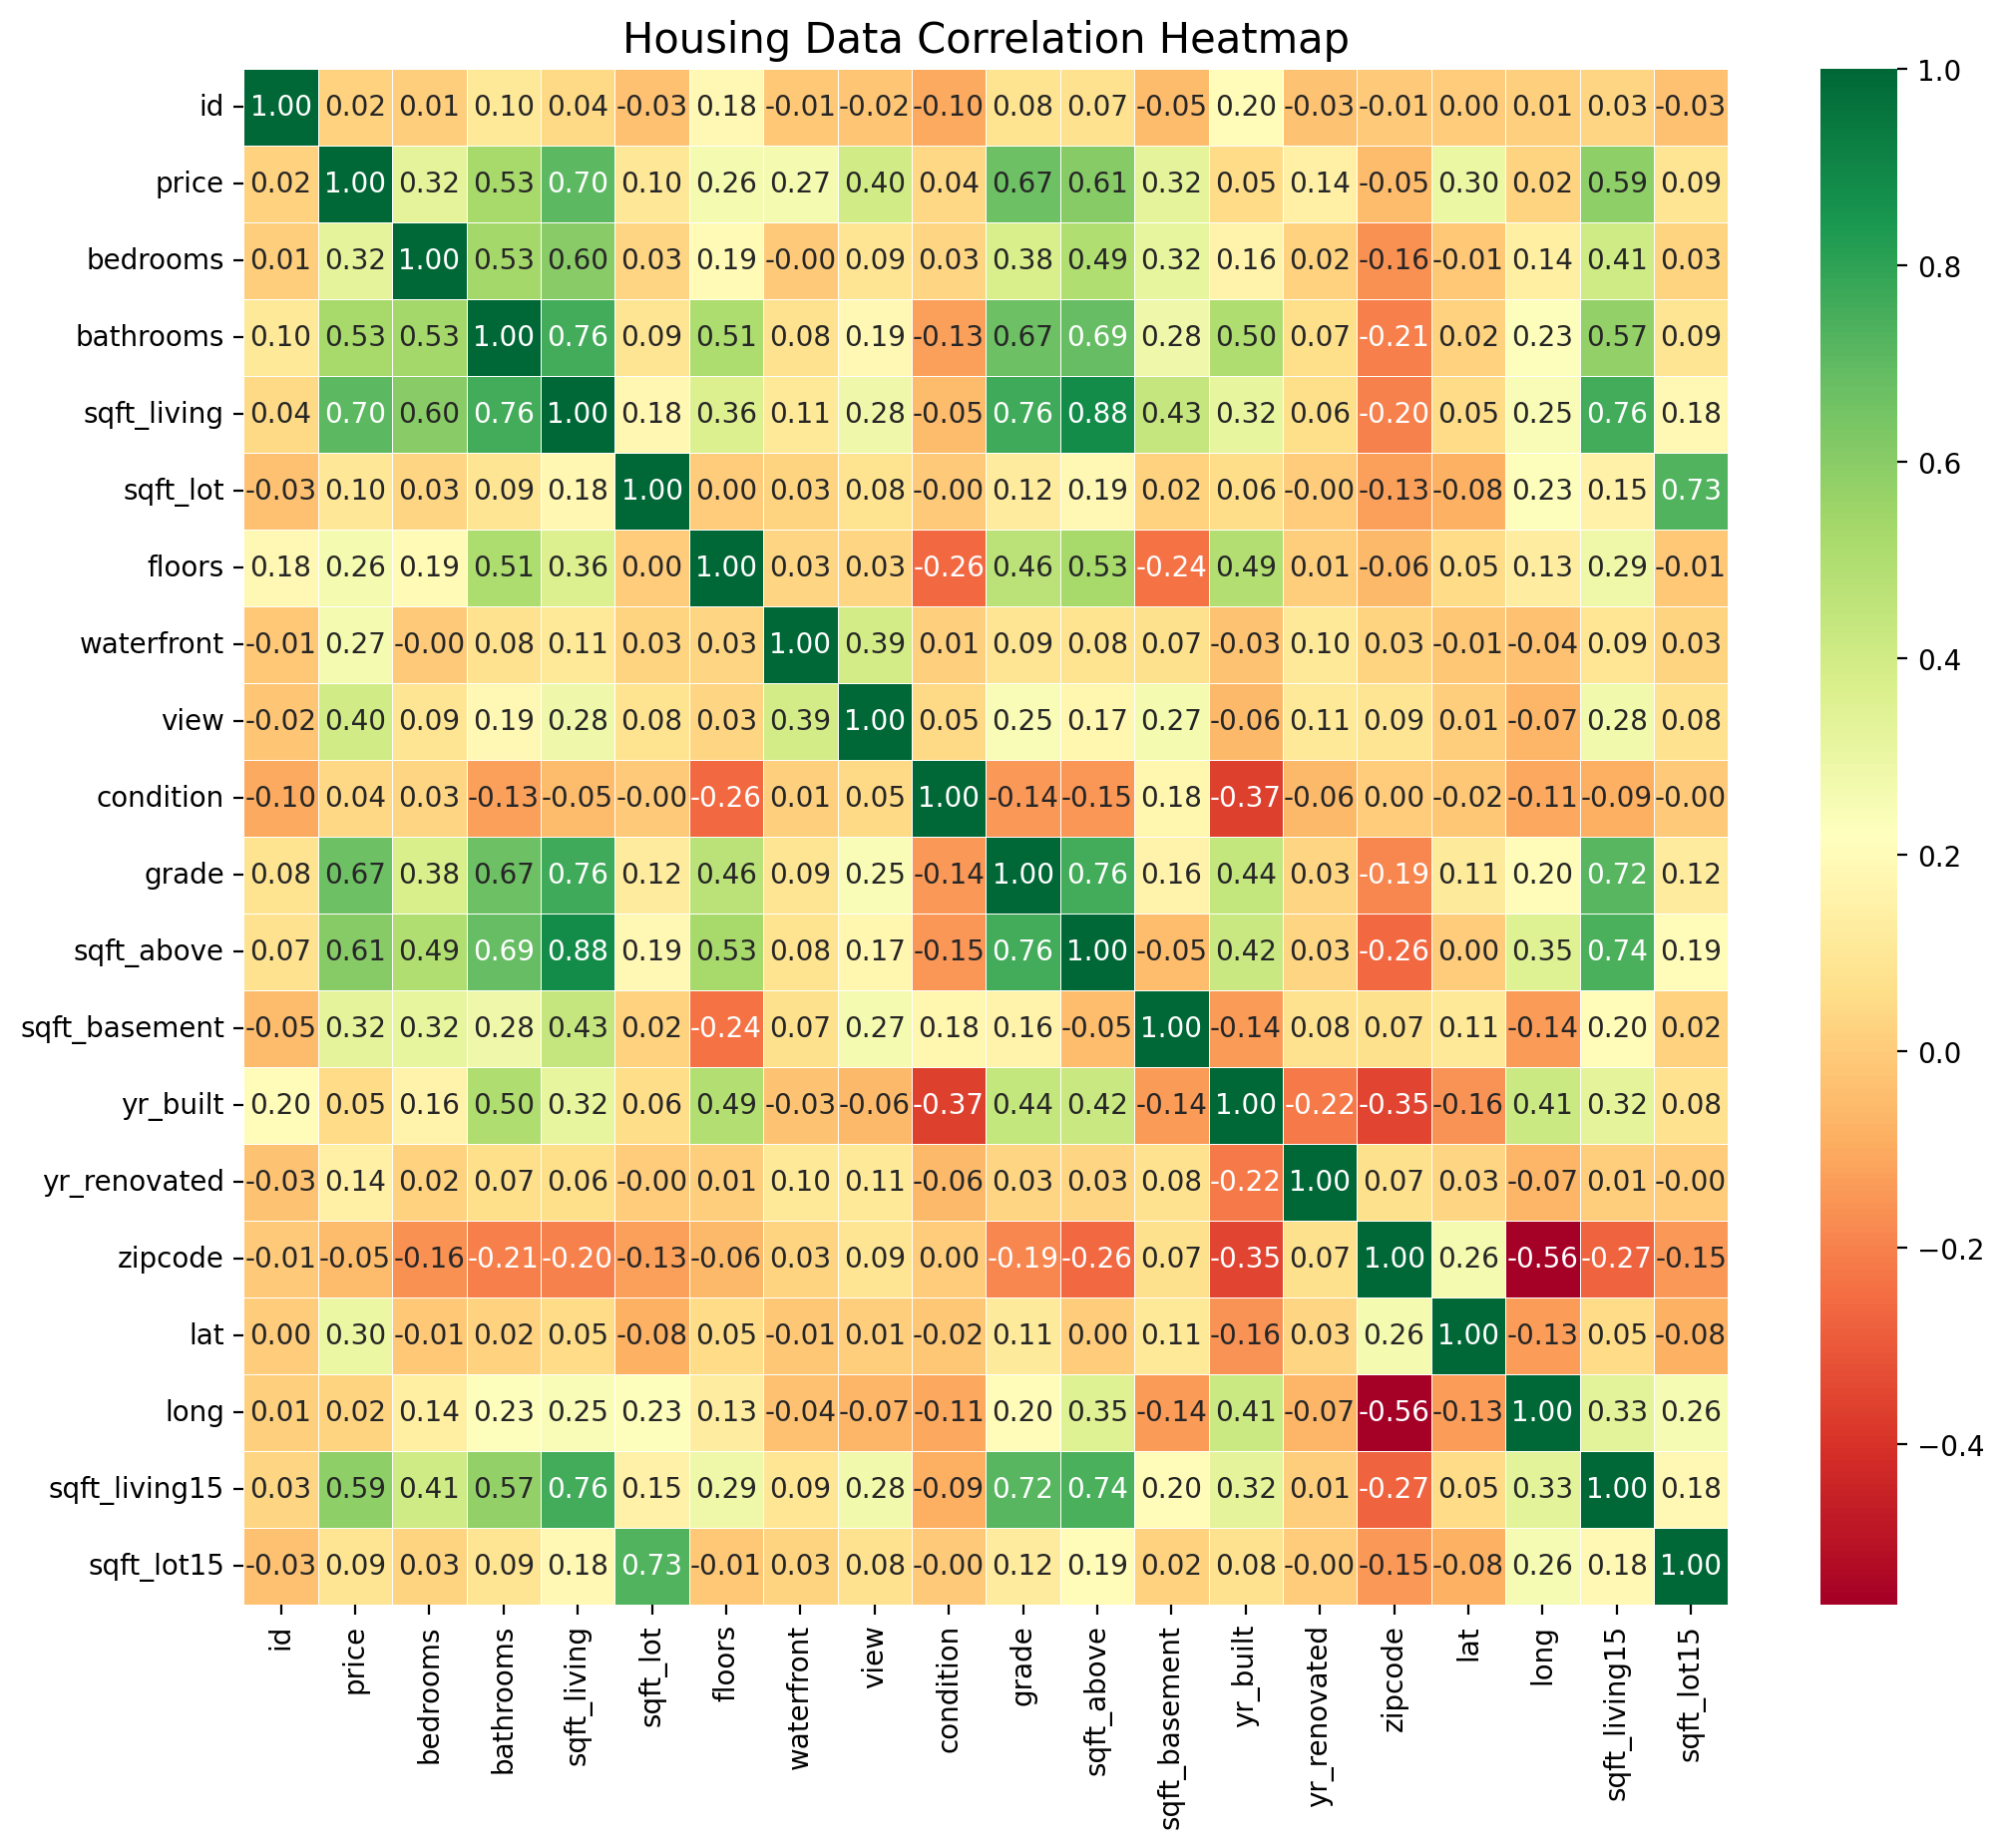

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno  # 결측치 확인용

# 1. 결측치 시각화 (선택 사항)
# 상관관계 계산 전, 데이터의 비어있는 부분을 먼저 확인합니다.
msno.matrix(data)
plt.show()

# 2. 상관계수 계산
# 주택가격 데이터의 모든 수치형 컬럼 간 상관관계를 계산합니다.
corr = data.corr(numeric_only=True)

# 3. 히트맵 시각화
plt.figure(figsize=(12, 10)) # 그래프 크기 설정

# annot=True: 수치 표시, cmap: 색상 테마, fmt: 소수점 자리수
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.2)

plt.title('Housing Data Correlation Heatmap', fontsize=15)
plt.show()

price와 연관성이 높은 피처는 bathrooms, grade, sqft_above, sqft_living15 이므로 이들을 가지고 price를 예측할 수 있는 모델을 만들어보자

Text(0.5, 1.02, 'House Price & Key Features Pair Plot')

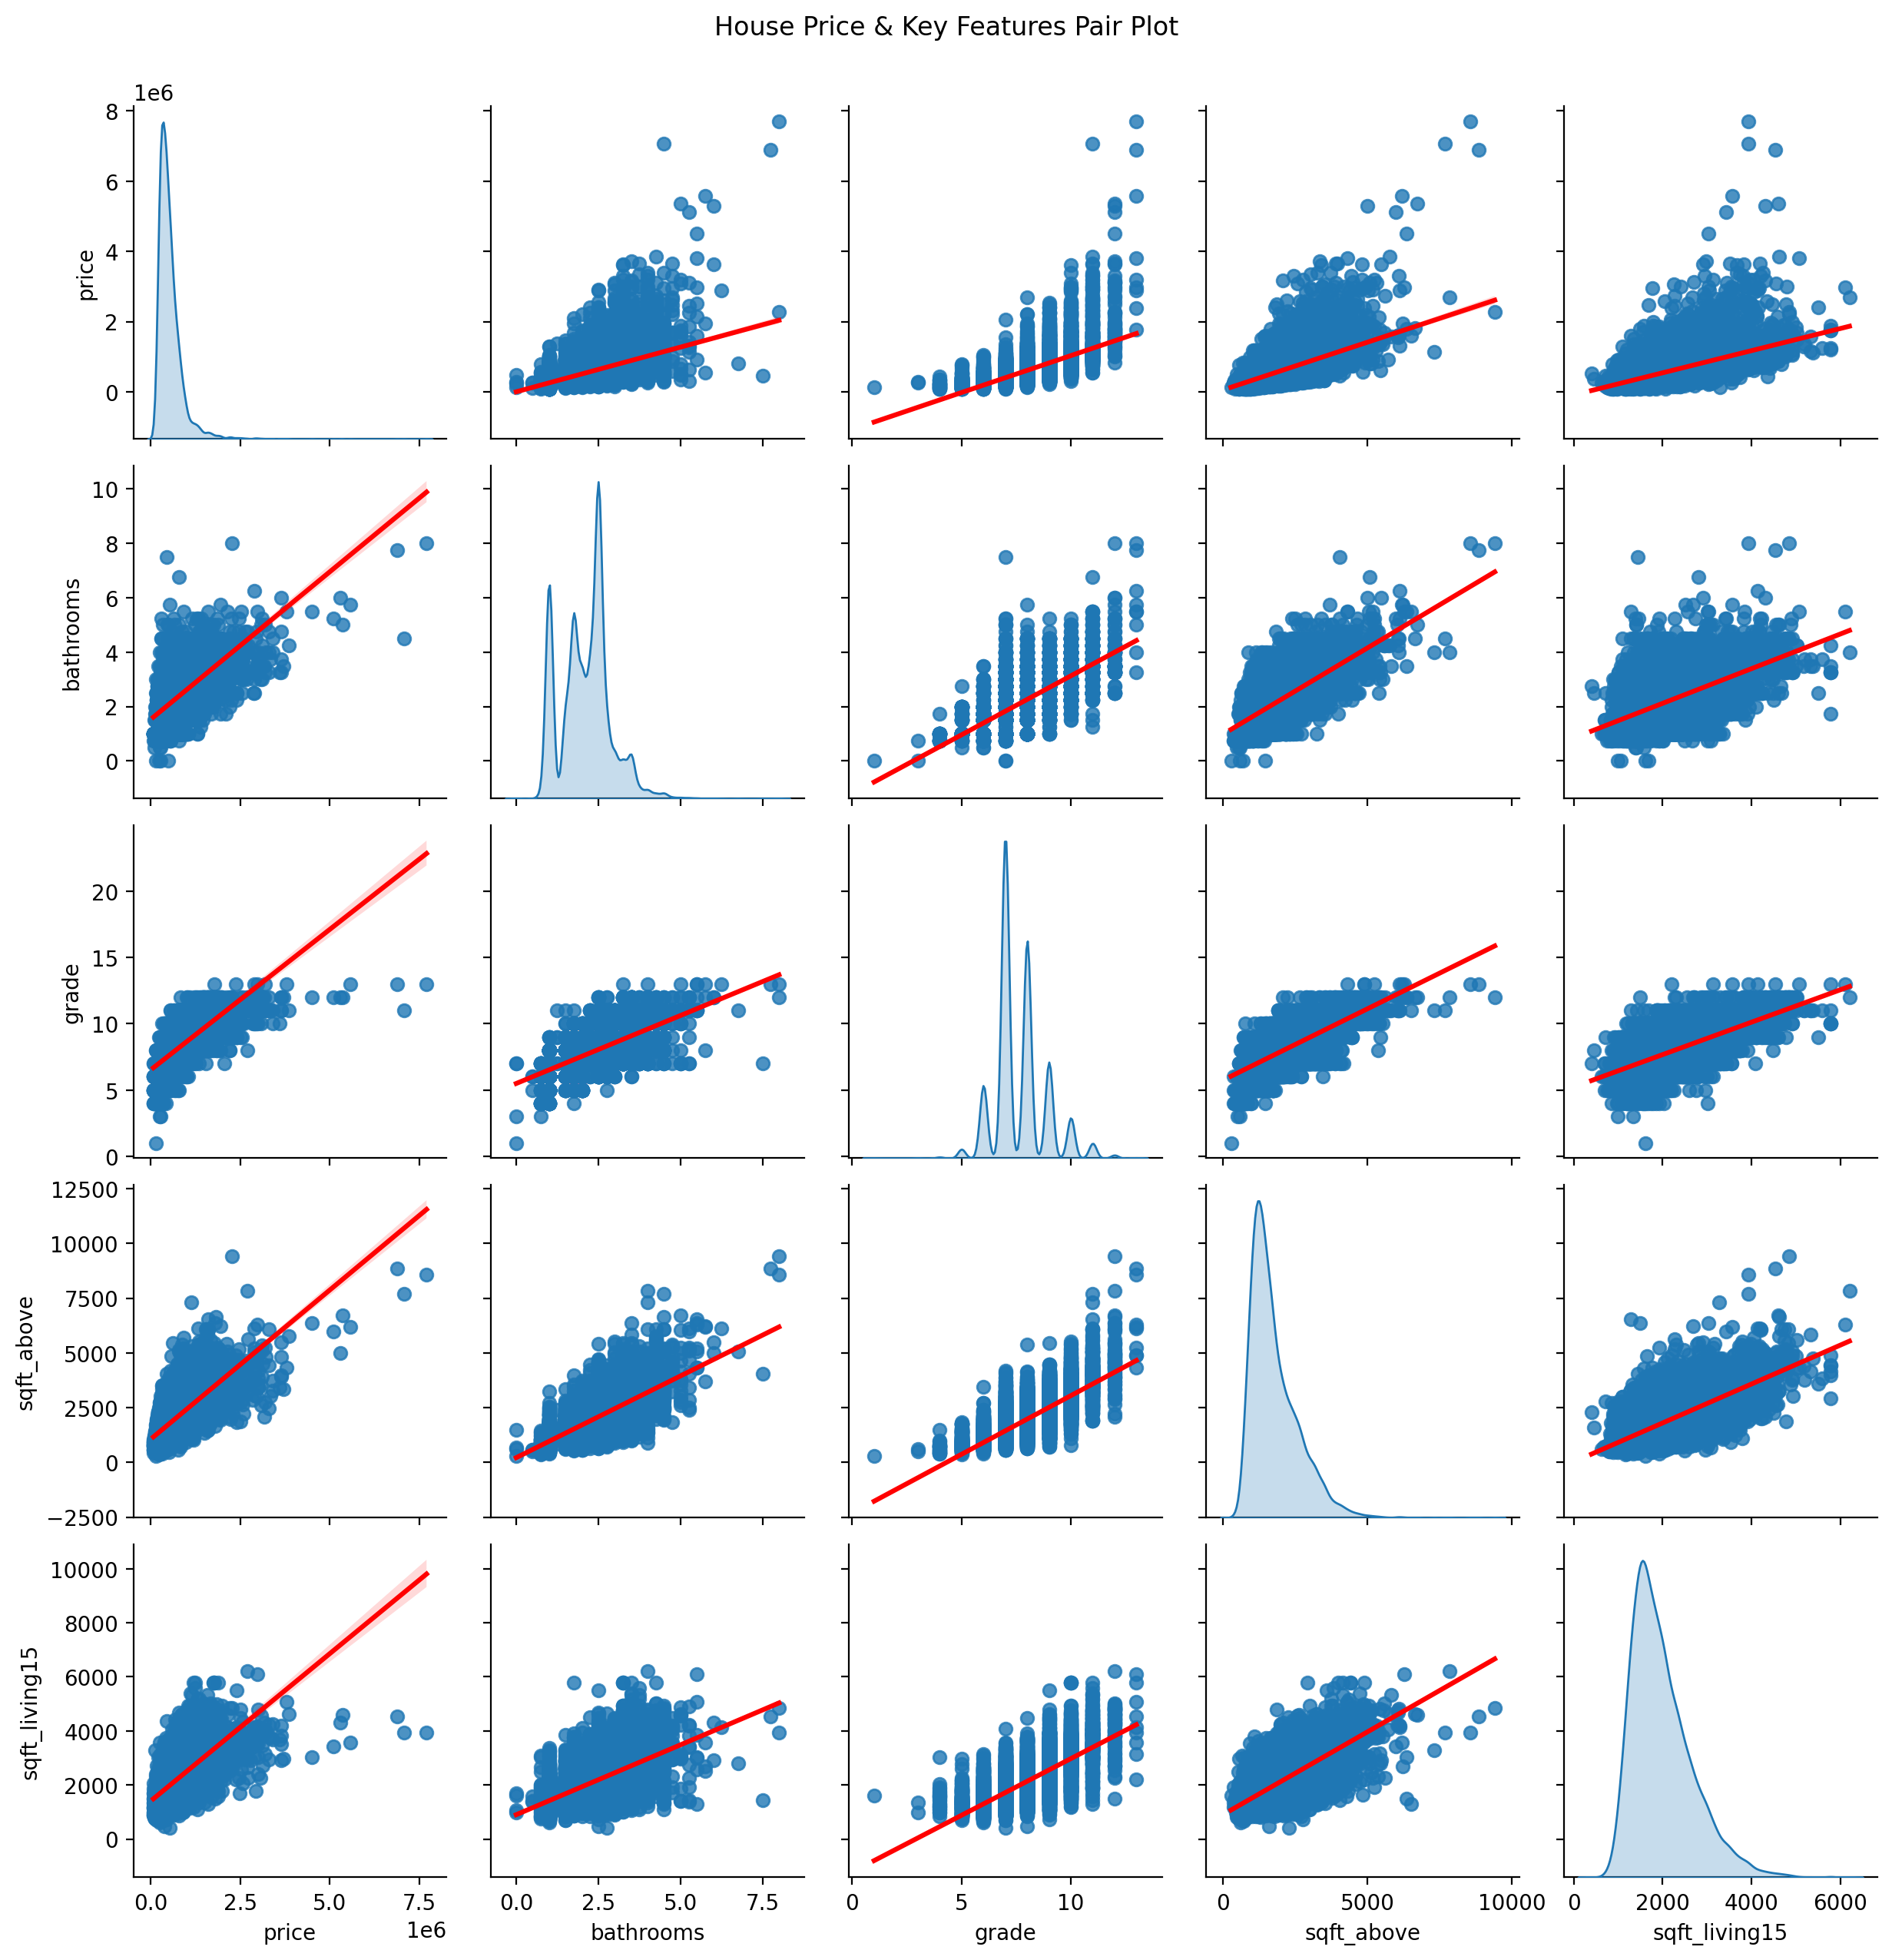

In [67]:
# 1. 데이터 로드
# 2. 분석할 피처 리스트 정의
# 'price'를 포함하여 총 5개 컬럼 선택
target_features = ['price', 'bathrooms', 'grade', 'sqft_above', 'sqft_living15']

# 3. Pair Plot 그리기
# kind='reg'를 추가하면 산점도 위에 회귀선이 그려져 연관성을 더 쉽게 파악할 수 있습니다.
sns.pairplot(df[target_features], kind='reg', diag_kind='kde', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('House Price & Key Features Pair Plot', y=1.02) # 제목 추가

In [68]:
# 1. 데이터 로드 및 피처 선택

target_features = ['price', 'bathrooms', 'grade', 'sqft_above', 'sqft_living15']

# 2. 상관계수 행렬 계산
corr_matrix = df[target_features].corr()

# 3. 상관계수 수치 출력
print("--- [Price와의 상관계수 순위] ---")
print(corr_matrix['price'].sort_values(ascending=False))
print("\n")

--- [Price와의 상관계수 순위] ---
price            1.000000
grade            0.667211
sqft_above       0.608577
sqft_living15    0.586419
bathrooms        0.525479
Name: price, dtype: float64




In [69]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np# 1. 데이터 준비
features = ['bathrooms', 'grade', 'sqft_above', 'sqft_living15']
X = df[features]
y = df['price']

# 로그 변환 (집값은 분포가 치우쳐 있어 로그를 취하면 예측 성능이 올라갑니다)
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 2. 모델 리스트
models = [
    ['LinearRegression', LinearRegression()],
    ['RandomForest', RandomForestRegressor(n_estimators=100)],
    ['XGBoost', XGBRegressor(n_estimators=100, learning_rate=0.1)]
]

# 3. 성능 비교 (RMSE)
for name, model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name} RMSE: {rmse:.4f}")





LinearRegression RMSE: 0.3564
RandomForest RMSE: 0.3641
XGBoost RMSE: 0.3433


LinearRegression과 RandomForest 그리고 XGBoost를 비교한 결과 RandomForest가 성능적으로 우수한 것을 알 수 있었다

In [70]:
# 1. 데이터 로드 (경로는 이전과 동일하게 설정)

sub_data_path = '/content/sample_data/kaggle-kakr-housing-data/data/test.csv'


train=pd.read_csv(train_data_path)
test = pd.read_csv(sub_data_path)

# 2. 사용할 피처 선택 (상관성 높았던 4개)
features = ['bathrooms', 'grade', 'sqft_above', 'sqft_living15']

X_train = train[features]
y_train = np.log1p(train['price']) # 타겟 값 로그 변환 (성능 향상)
X_test = test[features]

# 3. 모델 생성 및 학습
# n_estimators(나무 개수)와 random_state(결과 고정) 설정
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

In [71]:
# 4. 예측 수행
# 학습 때 로그 변환을 했으므로, 결과값에 다시 지수함수(exp)를 취해 원래 가격으로 복구합니다.
preds_log = rf_model.predict(X_test)
final_preds = np.expm1(preds_log)

# 5. 결과 확인
test['price_predicted'] = final_preds
print(test[['bathrooms', 'grade', 'price_predicted']].head())




   bathrooms  grade  price_predicted
0       2.25      7     4.072042e+05
1       3.00      7     3.822358e+05
2       4.50     11     1.454513e+06
3       1.00      7     3.589035e+05
4       2.50      7     3.576234e+05


In [72]:
data_dir = '/content/sample_data/kaggle-kakr-housing-data/data'
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission.head()



,id,price
0,15035,100000
1,15036,100000
2,15037,100000
3,15038,100000
4,15039,100000


In [73]:
sub_id=test['id']
result = pd.DataFrame({
    'id' : sub_id,
    'price' : final_preds
})

result.head()

,id,price
0,15035,4.072042e+05
1,15036,3.822358e+05
2,15037,1.454513e+06
3,15038,3.589035e+05
4,15039,3.576234e+05


In [74]:
my_submission_path = join(data_dir, 'submission.csv')
result.to_csv(my_submission_path, index=False)

print(my_submission_path)

/content/sample_data/kaggle-kakr-housing-data/data/submission.csv
